# RELATÓRIO TÉCNICO — ANÁLISE DE FATORES RELACIONADOS À RECEITA

## 1. Objetivo e escopo

Documentar a metodologia, as validações, os tratamentos e os resultados da análise exploratória dos dados de mídia paga, com foco em **identificar quais variáveis se relacionam com a receita**. Este relatório é a versão técnica do Relatório Gerencial e cobre as etapas de importação, validação, tratamento, análise descritiva e análise de relação entre variáveis (seções 1 a 7.3 do notebook de análise).

**Fora do escopo:** modelagem preditiva, testes de hipótese e inferência causal.

> *Nota: os gráficos deste notebook foram pré-renderizados a partir dos resultados da análise. Ao executar as células com o CSV original, todos são regenerados.*

## 2. Fonte de dados e reprodutibilidade

| Item | Descrição |
|---|---|
| Arquivo | `bq-results-20260904-205126-1788555238314.csv` (exportação do BigQuery) |
| Dimensão original | 23.439 linhas × 29 colunas |
| Período | 03/11/2025 a 31/08/2026 (302 dias, todos com registro) |
| Granularidade | Uma linha por campanha (`campaign_key`) por dia |
| Duplicados | 0 linhas duplicadas |
| Base final (`tratada`) | 17.992 linhas × 28 colunas |

**Principais colunas**

- Dimensões: `report_date`, `campaign_key`, `campaign_name`, `platform`, `campaign_group`, `funnel_stage`, `campaign_key_type`.
- Métricas: `receita`, `orders`, `visits`, `investimento`, `impressions`, `clicks`, `roas`.
- Decomposição da receita por método de atribuição: `receita_safe_ad`, `receita_excecao_manual`, `receita_pmax_sem_anuncio`, `receita_por_nome_campanha`, `receita_anuncio_ambiguo`, `receita_outro`, `receita_nao_casado`.
- Decomposição do investimento: `investimento_anuncio`, `investimento_campanha`.
- Textuais de classificação: `motivos_receita`, `motivos_investimento`.
- Percentuais (removidos no tratamento): `pct_receita_assertiva`, `pct_receita_anuncio_ambiguo`, `pct_receita_assertiva_alta`, `pct_investimento_anuncio`.

A célula abaixo reconstrói a base `tratada` com a mesma lógica do notebook de análise, e permite executar o relatório de forma independente.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option('display.float_format', lambda x: '%.2f' % x)

# Reconstrução da base "tratada" (mesma lógica do notebook de análise),
# para que este relatório possa ser executado de forma independente.
df = pd.read_csv('bq-results-20260904-205126-1788555238314.csv')
df['report_date'] = pd.to_datetime(df['report_date'].str.strip(), format="%Y-%m-%d")

plataformas_sem_receita = ['Awin', 'Kayak', 'Skyscanner', 'DV360', 'Vivo']
df_receita = df[~df['platform'].isin(plataformas_sem_receita)]

df_receita_sem_pct = df_receita.drop(columns=[
    'pct_receita_assertiva', 'pct_receita_anuncio_ambiguo',
    'pct_receita_assertiva_alta', 'pct_investimento_anuncio'
])

numericas_zero = [
    "receita", "orders", "visits", "investimento", "impressions", "clicks",
    "receita_safe_ad", "receita_excecao_manual", "receita_pmax_sem_anuncio",
    "receita_por_nome_campanha", "receita_outro", "receita_anuncio_ambiguo", "receita_nao_casado",
    "investimento_anuncio", "investimento_campanha",
]
tratada = df_receita_sem_pct.copy()
for col in numericas_zero:
    tratada[col] = tratada[col].fillna(0)

tratada["motivos_receita"] = tratada["motivos_receita"].fillna("sem_receita")
tratada["motivos_investimento"] = tratada["motivos_investimento"].fillna("sem_investimento")

tratada["roas"] = tratada["receita"] / tratada["investimento"].replace(0, np.nan)
tratada["roas"] = tratada["roas"].fillna(0)

tratada["mes"] = tratada["report_date"].dt.month
tratada["ano"] = tratada["report_date"].dt.year
tratada["ano_mes"] = tratada["report_date"].dt.to_period("M").astype(str)

tratada = tratada[tratada['funnel_stage'] != 'NÃO IDENTIFICADO']

## 3. Validação da base

### 3.1 Estrutura e nulos

Foram verificados tipos, duplicados e nulos. As colunas de receita (`receita`, `orders`, `visits` e os 7 métodos de atribuição) têm o **mesmo número de nulos (9.305; 39,70%)**, o que indica que a ausência é da linha inteira de receita, e não de campos isolados.

| Coluna | Nulos | % |
|---|---|---|
| `receita`, `orders`, `visits`, métodos de atribuição, `motivos_receita` | 9.305 | 39,70% |
| `investimento`, `investimento_campanha` | 6.149 | 26,23% |
| `impressions` | 6.176 | 26,35% |
| `clicks` | 6.510 | 27,77% |
| `roas` | 15.712 | 67,03% |
| `pct_receita_assertiva`, `pct_receita_anuncio_ambiguo`, `pct_receita_assertiva_alta` | 16.960 | 72,36% |
| `pct_investimento_anuncio`, `motivos_investimento` | 7.370 | 31,44% |

### 3.2 Valores "NÃO IDENTIFICADO"

| Coluna | % de linhas |
|---|---|
| `campaign_group` | 18,67% |
| `funnel_stage` | 16,92% |
| `campaign_name` | 2,58% |

### 3.3 Receita nula por plataforma

Na base original, o percentual de linhas com receita nula varia muito entre plataformas:

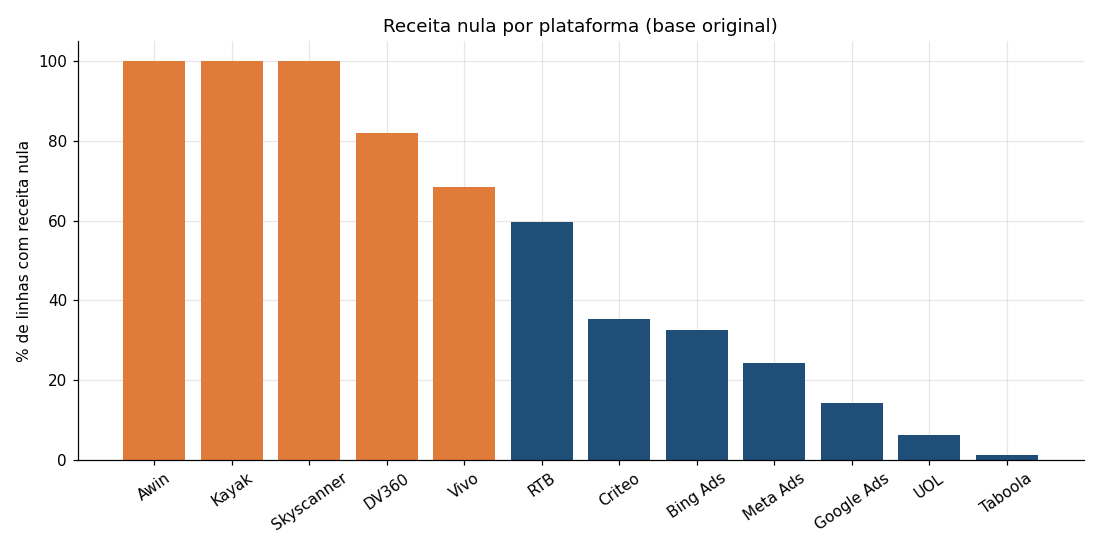

In [ ]:
# % de linhas com receita nula por plataforma (base original)

total = df.groupby("platform").size()
nulos = df[df["receita"].isnull()].groupby("platform").size()
(nulos / total * 100).fillna(0).sort_values(ascending=False).plot(kind="bar", figsize=(10, 5))
plt.title("Receita nula por plataforma (base original)")
plt.ylabel("% de linhas com receita nula")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

### 3.4 Decisão de exclusão de plataformas

| Plataforma | Linhas | Evidência | Decisão |
|---|---|---|---|
| Awin | 302 | 100% de receita nula | Excluída da análise de receita |
| Kayak | 3.788 | 100% de receita nula | Excluída da análise de receita |
| Skyscanner | 976 | 100% de receita nula | Excluída da análise de receita |
| DV360 | 50 | 41 nulos e 9 zeros; nenhum valor positivo | Excluída da análise de receita |
| Vivo | 270 | Só 1 valor diferente de 0/nulo (R$ 1.314,42) | Excluída da análise de receita |

A exclusão vale **apenas para a análise de receita**. Total removido: 5.386 linhas (23.439 → 18.053).

### 3.5 Nulos nas demais plataformas

Nas 7 plataformas mantidas, 22,23% das linhas têm receita nula e 33,47% não têm investimento informado. Quanto à receita nula por combinação plataforma × etapa, os maiores percentuais são: UOL/Conversão (70,32%), Criteo/Conversão (43,87%), Taboola/Conversão (40,37%), Bing Ads/Conversão (37,24%), Google Ads/Consideração (35,01%), RTB/Conversão (34,01%) e Google Ads/Conversão (32,91%).

Interpretação adotada: nulo em receita significa **ausência de receita atribuída no dia**, tratado como 0.

## 4. Tratamento dos dados

| # | Etapa | Detalhe | Efeito |
|---|---|---|---|
| 1 | Datas | `report_date`: `strip()` e conversão para `datetime` (`%Y-%m-%d`) | Permite agregação temporal |
| 2 | Exclusão de plataformas | Awin, Kayak, Skyscanner, DV360, Vivo | 23.439 → 18.053 linhas |
| 3 | Remoção de colunas `pct_*` | 4 colunas com alto percentual de nulos (36,68% a 64,12% na base filtrada) | 29 → 25 colunas |
| 4 | Preenchimento numérico | 15 colunas numéricas: `NaN` → 0 | Elimina nulos nas métricas |
| 5 | Preenchimento categórico | `motivos_receita` → `sem_receita`; `motivos_investimento` → `sem_investimento` | Elimina nulos categóricos |
| 6 | Recálculo do ROAS | `receita / investimento` (0 quando não há investimento) | Substitui o `roas` original (57,39% nulo) |
| 7 | Variáveis derivadas | `mes`, `ano`, `ano_mes` | Suporte à análise temporal |
| 8 | Remoção de `funnel_stage` = "NÃO IDENTIFICADO" | 61 linhas (RTB: 37; Criteo: 24) | 18.053 → **17.992** linhas |

Após o tratamento, `tratada` não tem nulos.

**Ressalvas do tratamento**

- O preenchimento com 0 assume que nulo significa "sem valor no dia". Para `investimento`, isso pode não ser verdade (o dado pode estar ausente, e não ser zero).
- O ROAS de linha é 0 quando não há investimento, mesmo que haja receita. Por isso, as análises agregadas usam **soma da receita ÷ soma do investimento**, e não a média do ROAS de linha.

## 5. Estatística descritiva

| Variável | Média | Mediana | Q3 | Máximo | Desvio padrão |
|---|---|---|---|---|---|
| `receita` | 42.048,01 | 0,00 | 2.878,88 | 4.265.516,27 | 280.206,84 |
| `orders` | 24,37 | 0 | 2 | 2.412 | 163,02 |
| `visits` | 592,57 | 11 | 108 | 42.968 | 3.542,52 |
| `investimento` | 3.096,61 | 242,31 | 1.718,75 | 476.439,13 | 11.907,54 |
| `impressions` | 133.074,26 | 3.886,50 | 56.083,25 | 36.101.802 | 653.262,65 |
| `clicks` | 2.079,70 | 148 | 842,25 | 647.101 | 9.086,64 |

**Leitura**

- Todas as variáveis têm **forte assimetria à direita**: média muito acima da mediana e desvio padrão maior que a média.
- Para `receita`, Q1 = 0 e Q3 = 2.878,88, logo IQR = 2.878,88 e o limite superior de outliers (Q3 + 1,5 × IQR) é **R$ 7.197,20**. Como a distribuição é muito concentrada em poucas linhas, esse critério marca como outlier uma parcela grande de linhas com receita relevante, e não deve ser usado para excluir dados.
- `receita_outro` e `receita_nao_casado` somam 0 na base tratada, então não contribuem para a análise.

**Totais e retorno global (base tratada)**

| Métrica | Valor |
|---|---|
| Receita total | R$ 756.527.794,05 |
| Investimento total | R$ 55.714.189,98 |
| ROAS / ROI bruto | 13,58 |
| ROI líquido `(receita − investimento) / investimento` | 12,58 |

O investimento das 5 plataformas excluídas **não está** neste total, então o retorno global está calculado sobre um investimento parcial da mídia.

## 6. Análise por plataforma

### 6.1 Resumo

| Plataforma | Linhas | Receita (R$) | Investimento (R$) | ROAS | % inv. | % rec. |
|---|---|---|---|---|---|---|
| Google Ads | 8.543 | 641.676.595,57 | 42.467.207,96 | 15,11 | 76,22 | 84,82 |
| Bing Ads | 5.285 | 111.548.810,81 | 9.685.066,56 | 11,52 | 17,38 | 14,74 |
| Criteo | 253 | 2.175.400,91 | 355.868,59 | 6,11 | 0,64 | 0,29 |
| RTB | 898 | 469.783,47 | 1.040.628,22 | 0,45 | 1,87 | 0,06 |
| Taboola | 976 | 268.102,94 | 247.168,79 | 1,08 | 0,44 | 0,04 |
| UOL | 502 | 247.796,16 | 588.621,77 | 0,42 | 1,06 | 0,03 |
| Meta Ads | 1.535 | 141.304,19 | 1.329.628,09 | 0,11 | 2,39 | 0,02 |

### 6.2 Rankings de linhas

- As 20 maiores linhas por receita e as 20 maiores por investimento são todas do Google Ads.
- Apenas **2 linhas** estão nos dois top 20, ou seja, maior gasto não implica maior receita por linha.
- Filtrando linhas com investimento ≥ R$ 1.000, o top 20 por ROAS é formado por grupos de marca (`AON-MARCA-BRD`, `AON-MARCA`) e por `AON-US-PASSENGER-BRD`, em Google Ads e Bing Ads, com ROAS de linha de até 454,84.

### 6.3 Plataforma × etapa do funil

| Etapa | Plataforma | Receita (R$) | Investimento (R$) | ROAS |
|---|---|---|---|---|
| Conversão | Google Ads | 641.470.067,98 | 39.632.460,41 | 16,19 |
| Conversão | Bing Ads | 111.548.810,81 | 9.685.066,56 | 11,52 |
| Consideração | Google Ads | 206.527,59 | 1.775.511,37 | 0,12 |
| Awareness | Google Ads | 0,00 | 1.059.236,18 | 0,00 |
| Conversão | Meta Ads | 141.304,19 | 957.736,28 | 0,15 |
| Conversão | RTB | 469.783,47 | 864.998,68 | 0,54 |
| Conversão | UOL | 247.796,16 | 588.621,77 | 0,42 |
| Conversão | Criteo | 2.175.400,91 | 355.868,59 | 6,11 |
| Awareness | Meta Ads | 0,00 | 301.297,48 | 0,00 |
| Consideração | RTB | 0,00 | 175.629,54 | 0,00 |
| Consideração | Meta Ads | 0,00 | 70.594,33 | 0,00 |

### 6.4 Conversão e ticket médio

| Plataforma | Pedidos | Visitas | Taxa de conversão | Ticket médio (R$) |
|---|---|---|---|---|
| Bing Ads | 60.108 | 1.061.323 | 5,66% | 1.855,81 |
| Google Ads | 376.246 | 9.437.088 | 3,99% | 1.705,47 |
| Criteo | 1.389 | 42.321 | 3,28% | 1.566,16 |
| RTB | 268 | 13.610 | 1,97% | 1.752,92 |
| UOL | 86 | 4.905 | 1,75% | 2.881,35 |
| Taboola | 204 | 39.991 | 0,51% | 1.314,23 |
| Meta Ads | 93 | 62.280 | 0,15% | 1.519,40 |

Taxa de conversão = `orders / visits`; ticket médio = `receita / orders`. O ticket do UOL vem de apenas 86 pedidos e deve ser lido com cautela.

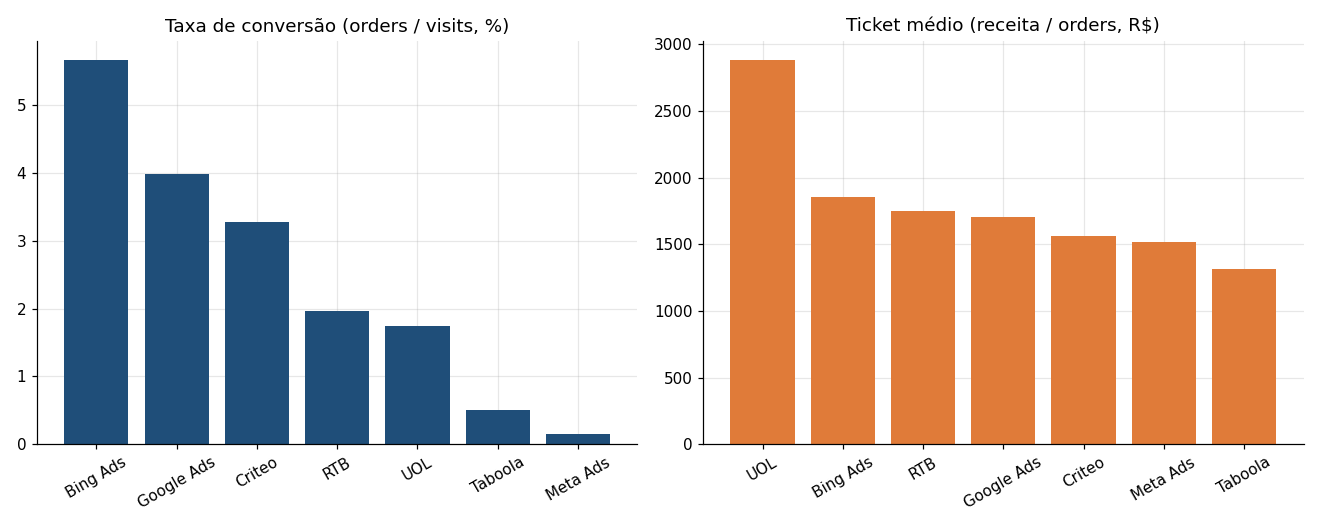

In [ ]:
# Taxa de conversão e ticket médio por plataforma

g = tratada.groupby("platform").agg(
    receita=("receita", "sum"), orders=("orders", "sum"), visits=("visits", "sum")
)
g["taxa_conversao_pct"] = g["orders"] / g["visits"] * 100
g["ticket_medio"] = g["receita"] / g["orders"]

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 4.8))
g["taxa_conversao_pct"].sort_values(ascending=False).plot(kind="bar", ax=a1)
a1.set_title("Taxa de conversão (orders / visits, %)")
g["ticket_medio"].sort_values(ascending=False).plot(kind="bar", ax=a2, color="tab:orange")
a2.set_title("Ticket médio (receita / orders, R$)")
plt.tight_layout()
plt.show()

## 7. Análise temporal

### 7.1 Visão mensal

| Mês | Receita (R$) | Investimento (R$) | Pedidos | Dias | ROAS | % da receita |
|---|---|---|---|---|---|---|
| 2025-11 | 15.205.528,66 | 8.983.283,04 | 8.507 | 28 | 1,69 | 2,01 |
| 2025-12 | 19.889.516,07 | 5.730.611,44 | 10.774 | 31 | 3,47 | 2,63 |
| 2026-01 | 52.533.343,31 | 3.914.053,38 | 31.941 | 31 | 13,42 | 6,94 |
| 2026-02 | 87.176.810,40 | 4.282.808,56 | 53.398 | 28 | 20,36 | 11,52 |
| 2026-03 | 109.194.575,70 | 7.877.464,75 | 62.069 | 31 | 13,86 | 14,43 |
| 2026-04 | 103.815.926,07 | 5.559.413,68 | 58.268 | 30 | 18,67 | 13,72 |
| 2026-05 | 99.785.863,45 | 4.702.244,18 | 58.477 | 31 | 21,22 | 13,19 |
| 2026-06 | 80.573.031,63 | 5.733.084,86 | 47.927 | 30 | 14,05 | 10,65 |
| 2026-07 | 69.739.956,15 | 4.412.627,11 | 43.881 | 31 | 15,80 | 9,22 |
| 2026-08 | 118.613.242,61 | 4.518.598,99 | 63.152 | 31 | 26,25 | 15,68 |

Novembro/2025 tem o maior investimento mensal (R$ 8,98 milhões) e a menor receita. Agosto/2026 tem o maior ROAS (26,25) e a maior receita.

### 7.2 Dias extremos

| Melhores dias | Receita (R$) | ROAS |
|---|---|---|
| 11/08/2026 | 5.364.414,85 | 35,41 |
| 31/03/2026 | 5.161.326,70 | 17,26 |
| 17/08/2026 | 5.079.544,22 | 34,73 |

| Piores dias | Receita (R$) | ROAS |
|---|---|---|
| 03/11/2025 | 39.494,21 | 0,12 |
| 05/11/2025 | 48.531,12 | 0,12 |
| 06/11/2025 | 92.262,19 | 0,39 |
| 04/11/2025 | 112.063,86 | 0,42 |

Entre os 10 melhores dias, 7 são de agosto/2026; entre os 20 melhores, 11.

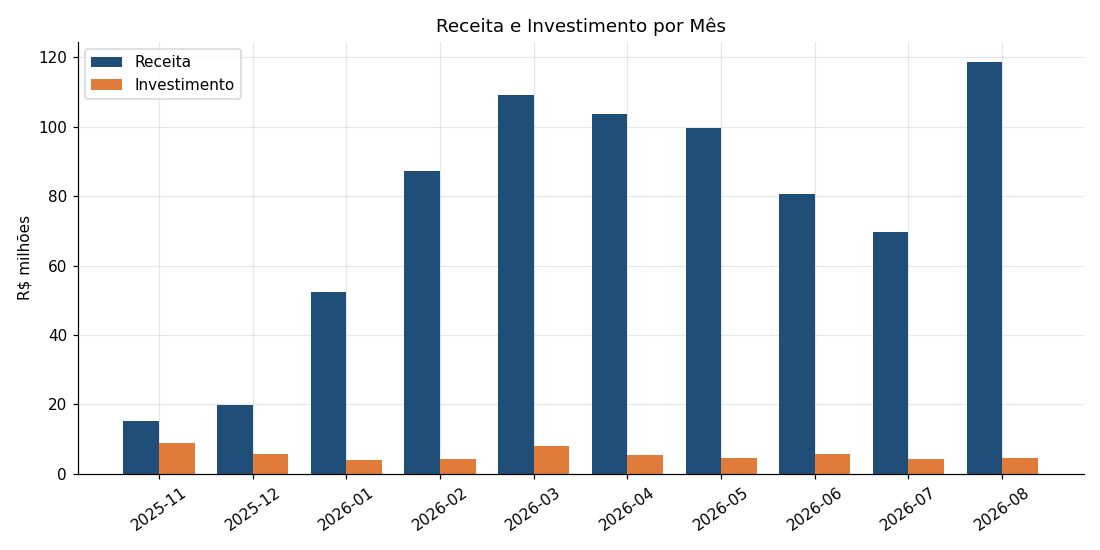

In [ ]:
# Receita e investimento por mês

mensal = tratada.groupby("ano_mes")[["receita", "investimento"]].sum() / 1e6
ax = mensal.plot(kind="bar", figsize=(10, 5))
ax.set_title("Receita e Investimento por Mês")
ax.set_ylabel("R$ milhões")
plt.xticks(rotation=35)
plt.tight_layout()
plt.show()

## 8. Método de atribuição da receita

### 8.1 Composição no período

A receita de cada linha é a soma dos métodos de atribuição (`receita_outro` e `receita_nao_casado` são zero). Pelas médias por linha:

| Método | Média por linha (R$) | % da receita |
|---|---|---|
| `receita_excecao_manual` | 21.816,37 | 51,9% |
| `receita_anuncio_ambiguo` | 8.077,83 | 19,2% |
| `receita_por_nome_campanha` | 6.375,61 | 15,2% |
| `receita_pmax_sem_anuncio` | 3.990,34 | 9,5% |
| `receita_safe_ad` | 1.787,86 | 4,3% |

### 8.2 Combinações em `motivos_receita`

| `motivos_receita` | Linhas | Receita (R$) | ROAS |
|---|---|---|---|
| anuncio_ambiguo, excecao_manual, safe_ad | 156 | 380.039.554,44 | 32,29 |
| anuncio_ambiguo, excecao_manual, pmax_sem_anuncio, safe_ad | 55 | 133.783.222,31 | 39,56 |
| por_nome_campanha | 5.552 | 114.709.894,29 | 18,57 |
| pmax_sem_anuncio | 1.912 | 69.597.931,73 | 7,58 |
| excecao_manual, safe_ad | 13 | 20.767.048,59 | 23,69 |
| anuncio_ambiguo, pmax_sem_anuncio, safe_ad | 566 | 12.196.976,84 | 3,50 |
| anuncio_ambiguo, safe_ad | 506 | 7.720.249,82 | 2,32 |
| anuncio_ambiguo, pmax_sem_anuncio | 335 | 5.667.453,83 | 11,03 |
| safe_ad | 3.241 | 5.487.517,40 | n/d |
| anuncio_ambiguo | 1.348 | 3.804.352,21 | n/d |
| pmax_sem_anuncio, safe_ad | 356 | 2.753.592,59 | n/d |
| sem_receita | 3.952 | 0,00 | 0 |

As três combinações que contêm `excecao_manual` (156, 55 e 13 linhas) somam R$ 534,6 milhões, ou **~70,7% da receita total**. Nessas linhas, a receita total da linha entra na soma, e não apenas o componente de exceção manual. Para `motivos_investimento`: `campanha` 5.514 linhas, `anuncio` 4.882, `anuncio + campanha` 976 e `sem_investimento` 6.620.

### 8.3 Mudança de mix ao longo dos meses

% da receita mensal por método:

| Mês | safe_ad | excecao_manual | pmax_sem_anuncio | por_nome_campanha | anuncio_ambiguo |
|---|---|---|---|---|---|
| 2025-11 | 14,40 | 0,00 | 5,12 | 68,17 | 12,31 |
| 2025-12 | 11,28 | 0,00 | 12,01 | 55,16 | 21,55 |
| 2026-01 | 3,35 | 52,53 | 19,23 | 23,92 | 0,97 |
| 2026-02 | 0,57 | 72,53 | 13,82 | 11,66 | 1,42 |
| 2026-03 | 7,86 | 68,42 | 8,96 | 12,01 | 2,74 |
| 2026-04 | 1,47 | 76,16 | 8,50 | 10,96 | 2,91 |
| 2026-05 | 1,96 | 72,55 | 11,08 | 11,73 | 2,68 |
| 2026-06 | 2,45 | 74,36 | 7,67 | 12,62 | 2,91 |
| 2026-07 | 4,54 | 20,28 | 6,60 | 13,22 | 55,36 |
| 2026-08 | 6,98 | 1,23 | 5,08 | 12,69 | 74,01 |

O mix muda de forma abrupta em **janeiro** (surge a exceção manual) e em **julho** (a exceção manual cai e o anúncio ambíguo passa a dominar). Hipóteses a verificar: mudança de regra ou de processo de atribuição, ou correções manuais aplicadas retroativamente a certos períodos. A análise não permite distinguir entre elas.

**Consequência analítica:** comparações de receita e ROAS entre meses misturam desempenho de mídia e efeito de método de atribuição. As linhas com `anuncio_ambiguo` também têm ROAS instável (32 a 39 em algumas combinações), coerente com valor concentrado em poucas linhas.

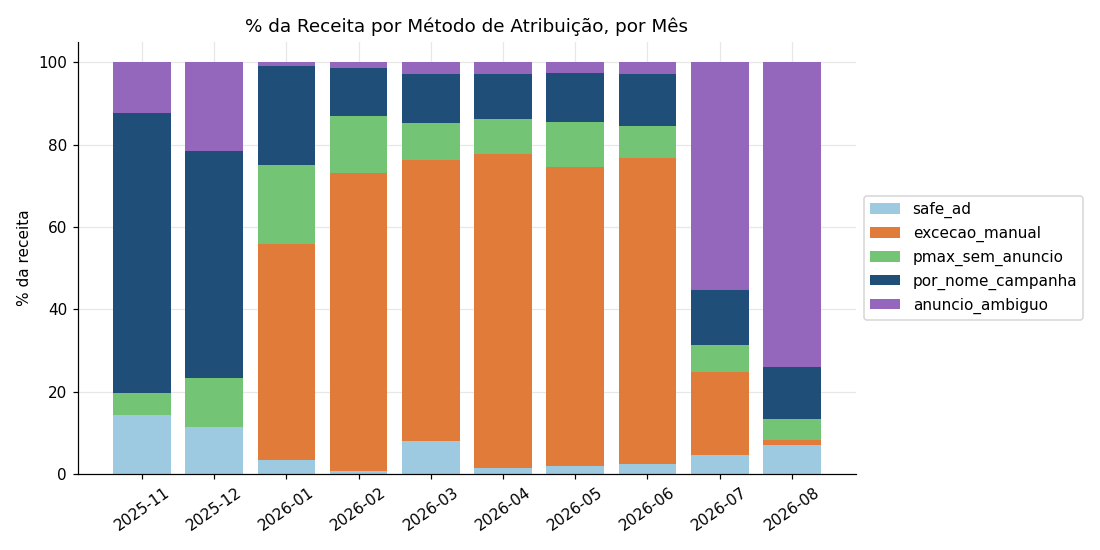

In [ ]:
# Composição da receita por método de atribuição, por mês (%)

metodos = [
    "receita_safe_ad", "receita_excecao_manual", "receita_pmax_sem_anuncio",
    "receita_por_nome_campanha", "receita_anuncio_ambiguo"
]
mix = tratada.groupby("ano_mes")[metodos].sum()
mix_pct = mix.div(mix.sum(axis=1), axis=0) * 100
display(mix_pct.round(2))

mix_pct.plot(kind="bar", stacked=True, figsize=(10, 5))
plt.title("% da Receita por Método de Atribuição, por Mês")
plt.ylabel("% da receita")
plt.xticks(rotation=35)
plt.legend(loc="center left", bbox_to_anchor=(1, 0.5))
plt.tight_layout()
plt.show()

## 9. Análise por etapa do funil

| Etapa | Linhas | Receita (R$) | Investimento (R$) | ROAS | % rec. | % inv. |
|---|---|---|---|---|---|---|
| Conversão | 16.625 | 756.321.266,46 | 52.331.921,08 | 14,45 | 99,97 | 93,93 |
| Consideração | 1.168 | 206.527,59 | 2.021.735,24 | 0,10 | 0,03 | 3,63 |
| Awareness | 199 | 0,00 | 1.360.533,66 | 0,00 | 0,00 | 2,44 |

A atribuição registrada só atribui receita relevante à etapa de Conversão. Isto é uma **característica do modelo de atribuição** (baseado em campanha, anúncio e nome), e não deve ser lido como ausência de contribuição das etapas superiores. Awareness só existe em Google Ads e Meta Ads, e Consideração em Google Ads, RTB e Meta Ads.

## 10. Análise por campanha

### 10.1 Grupos de campanha

| Grupo | Linhas | Receita (R$) | Investimento (R$) | ROAS |
|---|---|---|---|---|
| AON-MARCA-BRD | 545 | 559.561.420,16 | 22.518.715,19 | 24,85 |
| MARCA | 302 | 72.072.376,46 | 1.249.910,57 | 57,66 |
| AON-MARCA | 588 | 61.818.642,74 | 6.589.639,24 | 9,38 |
| AON-CONCORRENTES-NBRD | 541 | 6.088.678,34 | 2.127.803,00 | 2,86 |
| AON | 862 | 5.987.214,62 | 1.585.006,81 | 3,78 |
| AON-US-PASSENGER-BRD | 540 | 5.657.533,54 | 438.958,51 | 12,89 |
| CONCORRENTES | 299 | 5.126.061,91 | 934.597,14 | 5,48 |
| AON-GENERICA-NBRD | 542 | 4.564.426,67 | 2.453.231,35 | 1,86 |

Os três primeiros grupos somam R$ 693,45 milhões, ou **91,7%** da receita. O grupo `AON-MARCA-BRD` sozinho responde por 74,0%.

### 10.2 Campanhas (`campaign_name`)

| Campanha | Linhas | Receita (R$) | Investimento (R$) | ROAS |
|---|---|---|---|---|
| BRV_VA_GOOGLE_SEARCH_LF_AON-MARCA-BRD_PASS | 302 | 544.169.947,31 | 20.001.589,63 | 27,21 |
| BRV_VA_BING_SEARCH_LF_MARCA_PASS | 302 | 72.072.376,46 | 1.249.910,57 | 57,66 |
| BRV_VA_GOOGLE_PMAX_LF_AON-MARCA_PASS | 302 | 60.001.780,13 | 5.895.171,85 | 10,18 |
| BRV_VA_BING_SEARCH_LF_AON-MARCA-BRD_PASS | 243 | 15.391.472,85 | 2.517.125,56 | 6,11 |
| BRV_VA_BING_DMAX_LF_AON_PASS | 301 | 5.987.214,62 | 413.700,67 | 14,47 |

A campanha líder responde por **71,9%** da receita total. As maiores campanhas têm ~300 linhas (quase todos os dias do período), então **tempo de exposição** contribui para o acúmulo.

### 10.3 `campaign_key` e `campaign_key_type`

- O ranking por `campaign_key` reproduz exatamente o ranking por `campaign_name` (mesmas linhas, receitas e ROAS), então as duas variáveis são equivalentes nesta análise.
- `campaign_key_type` é **determinada pela plataforma**: Google Ads e Meta Ads usam `id`; Bing Ads, Criteo, RTB, Taboola e UOL usam `name`. Não é uma variável independente e não deve ser interpretada como fator de receita.

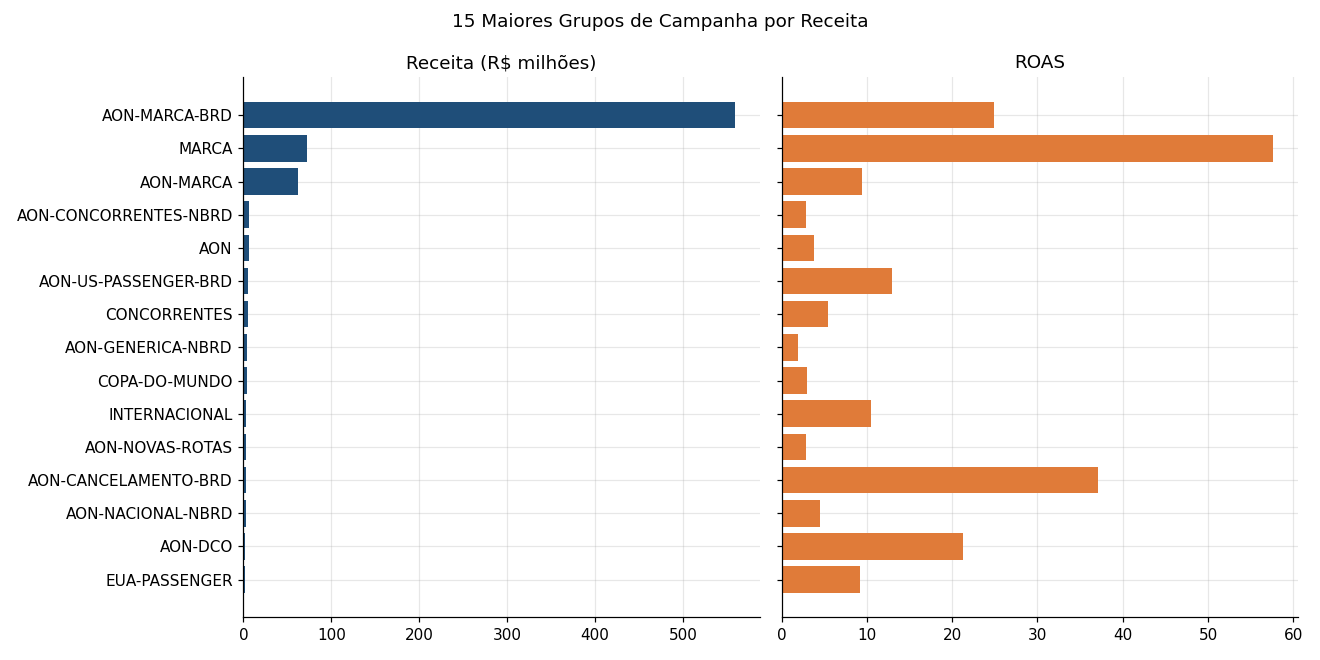

In [ ]:
# Grupos de campanha: receita e ROAS

grupo = (
    tratada.groupby("campaign_group")
    .agg(linhas=("receita", "size"), receita=("receita", "sum"), investimento=("investimento", "sum"))
)
grupo["roas"] = grupo["receita"] / grupo["investimento"].replace(0, np.nan)
grupo["pct_receita"] = grupo["receita"] / grupo["receita"].sum() * 100
grupo = grupo.sort_values("receita", ascending=False).head(15)
display(grupo)

fig, (a1, a2) = plt.subplots(1, 2, figsize=(12, 6), sharey=True)
a1.barh(grupo.index[::-1], grupo["receita"][::-1] / 1e6)
a1.set_title("Receita (R$ milhões)")
a2.barh(grupo.index[::-1], grupo["roas"][::-1], color="tab:orange")
a2.set_title("ROAS")
fig.suptitle("15 Maiores Grupos de Campanha por Receita")
plt.tight_layout()
plt.show()

## 11. Sazonalidade semanal

O número de ocorrências de cada dia da semana no período é de 43, exceto segunda-feira, que tem 44 (o período começa e termina em uma segunda). Por isso, a comparação usa a **média por dia** (total ÷ ocorrências).

| Dia | Receita total (R$) | Ocorrências | Média por dia (R$) |
|---|---|---|---|
| Segunda | 125.283.604,39 | 44 | 2.847.355 |
| Terça | 127.016.454,46 | 43 | 2.953.871 |
| Quarta | 125.314.828,51 | 43 | 2.914.298 |
| Quinta | 115.155.440,32 | 43 | 2.678.033 |
| Sexta | 107.964.240,53 | 43 | 2.510.796 |
| Sábado | 70.136.670,99 | 43 | 1.631.085 |
| Domingo | 85.656.554,85 | 43 | 1.992.013 |

Os totais e as médias apontam na mesma direção: terça a quarta/segunda no topo, com queda na sexta e mínimo no sábado. As médias foram calculadas a partir dos totais e da contagem de dias, e o resultado é descritivo (não controla por investimento, mix de campanhas ou sazonalidade mensal).

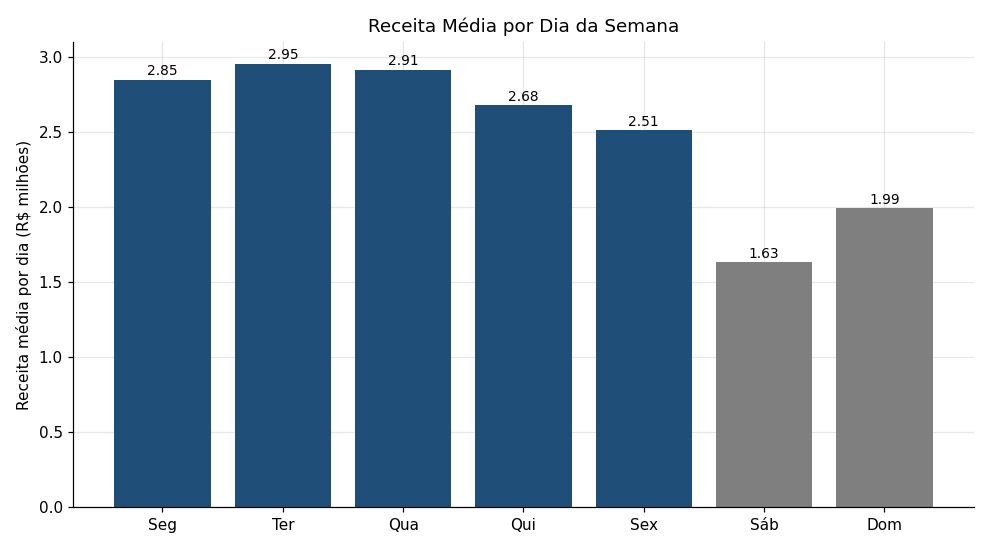

In [ ]:
# Receita média por dia da semana

tratada["dia_semana"] = tratada["report_date"].dt.day_name()
ordem_dias = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

dia = tratada.groupby("dia_semana").agg(
    dias=("report_date", "nunique"), receita=("receita", "sum"), investimento=("investimento", "sum")
).reindex(ordem_dias)
dia["receita_media_por_dia"] = dia["receita"] / dia["dias"]
dia["roas"] = dia["receita"] / dia["investimento"]
display(dia)

plt.figure(figsize=(9, 5))
plt.bar(dia.index, dia["receita_media_por_dia"] / 1e6)
plt.title("Receita Média por Dia da Semana")
plt.ylabel("Receita média por dia (R$ milhões)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

## 12. Correlação com a receita

Correlação de Pearson entre `receita` e as demais métricas numéricas (base tratada, nível de linha):

| Variável | Correlação |
|---|---|
| `orders` | 1,00 |
| `visits` | 0,98 |
| `investimento` | 0,69 |
| `clicks` | 0,61 |
| `impressions` | 0,01 |

**Leitura técnica**

- `orders` e `visits` são variáveis **mecanicamente ligadas** à receita (receita = pedidos × ticket). A correlação alta é esperada e não informa sobre fatores de negócio, apenas confirma consistência dos dados.
- `investimento` e `clicks` têm correlação moderada. A associação pode refletir escala comum (linhas maiores têm mais de tudo).
- `impressions` tem correlação ≈ 0, coerente com uma métrica de alcance sem relação linear direta com a receita final.
- Pearson é sensível a outliers, e a receita é extremamente assimétrica; poucas linhas de valor muito alto influenciam fortemente os coeficientes. Uma correlação de Spearman ou uma análise em log seria um complemento adequado.

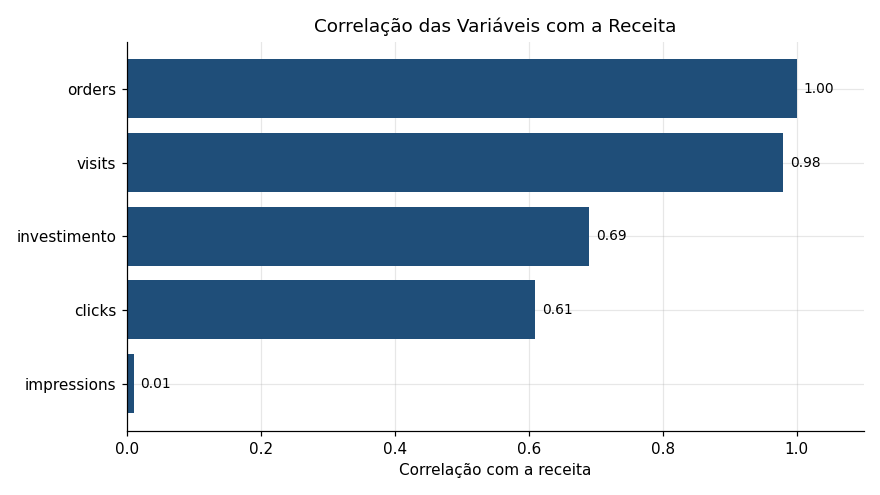

In [ ]:
# Correlação de Pearson e de Spearman com a receita

num_cols = ["receita", "orders", "visits", "investimento", "impressions", "clicks"]
comp = pd.DataFrame({
    "pearson": tratada[num_cols].corr(method="pearson")["receita"],
    "spearman": tratada[num_cols].corr(method="spearman")["receita"],
}).drop("receita").sort_values("pearson")
display(comp)

plt.figure(figsize=(8, 4.5))
plt.barh(comp.index, comp["pearson"])
plt.title("Correlação (Pearson) das Variáveis com a Receita")
plt.xlabel("Correlação")
plt.tight_layout()
plt.show()